In [1]:
import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from pathlib import Path

In [3]:
mne.viz.set_browser_backend("qt") # pip install pyqt5 mne-qt-browser
mne.set_log_level("ERROR")

In [4]:
PROJECT_PATH = Path.cwd()

DATA_DIR = "data"

raw = mne.io.read_raw_brainvision(
    PROJECT_PATH / DATA_DIR / "sub-01" / "eeg" / "sub-01_task-differentdoors_eeg.vhdr",
    preload = True
)

In [5]:
# downsample to 500Hz
raw.resample(sfreq=500, npad="auto")

# ogólny filtr
# - high-pass powyżej 0.1 Hz może zniekształcić ERPy
# - w badaniu użyto low-pass 30 Hz oraz ICLabel, lecz
#   ICLabel preferuje 1-100 Hz
raw.filter(l_freq=0.1, h_freq=100.0, fir_design="firwin")

# refka na Fz (z badania)
raw.add_reference_channels(ref_channels=["Fz"])

# re-reference na podstawie średniej ze wszystkich kanałów
raw.set_eeg_reference("average", projection=False)

# zmień nazwę M1/M2 na TP9/TP10 (najbliższy odpowiednik w montażu)
# raw.rename_channels({"M1": "TP9", "M2": "TP10"})

# usuń M1, M2 (nie używamy ich do re-reference)
raw.drop_channels(["M1", "M2"], on_missing="warn")

# ustaw montaż
raw.set_montage("easycap-M1", match_case=False, on_missing="warn")

raw.notch_filter(
    freqs=[60], # US; harmonics (120, 180...) already covered by low-pass
    method="fir",
    filter_length="10s"
)

<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 31 x 799840 (1599.7 s), ~189.2 MiB, data loaded>

In [6]:
# 20 kOhms (z badania)
IMP_THRESH = 20

# dla każdego kanału, jeśli wartość impedancji nie jest
# None i jest powyżej progu, zaznacz jako "bad"
bads = [
    channel for channel, info in raw.impedances.items()
    if channel in raw.ch_names
    and info.get("imp") is not None
    and info["imp"] > IMP_THRESH
]
raw.info["bads"] = bads

# ze względu na szum, raw.plot()
raw.info["bads"].append("T7")

print(f"Bads ({len(raw.info['bads'])}): {raw.info['bads']}")

Bads (1): ['T7']


In [7]:
raw_backup = raw.copy()

In [ ]:
raw_for_bad_segments = raw.copy()
fig_bad_segments = raw_for_bad_segments.plot(block=True)

In [33]:
raw.set_annotations(fig_bad_segments.mne.inst.annotations)

bad_only = [(o, d, desc)
            for o, d, desc in zip(raw.annotations.onset,
                                  raw.annotations.duration,
                                  raw.annotations.description)
            if desc.startswith('BAD_')]

print('bad_segments = [')
for onset, dur, desc in bad_only:
    print(f"    ({onset:.3f}, {dur:.3f}, '{desc}'),")
print(']')

bad_segments = [
    (144.449, 1.259, 'BAD_burst'),
    (594.367, 3.630, 'BAD_burst'),
    (599.392, 1.508, 'BAD_burst'),
    (694.231, 0.326, 'BAD_burst'),
    (745.447, 0.488, 'BAD_burst'),
    (805.968, 0.852, 'BAD_burst'),
    (814.383, 0.703, 'BAD_burst'),
    (1113.212, 2.989, 'BAD_burst'),
    (1408.841, 3.116, 'BAD_burst'),
    (1447.342, 3.826, 'BAD_burst'),
]


In [8]:
# wyłapane w raw.plot(), wpisane ręcznie
bad_segments = [
    (144.449, 1.259, 'BAD_burst'),
    (594.367, 3.630, 'BAD_burst'),
    (599.392, 1.508, 'BAD_burst'),
    (694.231, 0.326, 'BAD_burst'),
    (745.447, 0.488, 'BAD_burst'),
    (805.968, 0.852, 'BAD_burst'),
    (814.383, 0.703, 'BAD_burst'),
    (1113.212, 2.989, 'BAD_burst'),
    (1408.841, 3.116, 'BAD_burst'),
    (1447.342, 3.826, 'BAD_burst'),
]

onsets, durations, descriptions = zip(*bad_segments)
raw.set_annotations(raw.annotations + mne.Annotations(
    onset=list(onsets),
    duration=list(durations),
    description=list(descriptions),
    orig_time=raw.info['meas_date'],
))

raw.annotations

<Annotations | 1612 segments: BAD_burst (10), Comment/ControlBox is not ...>

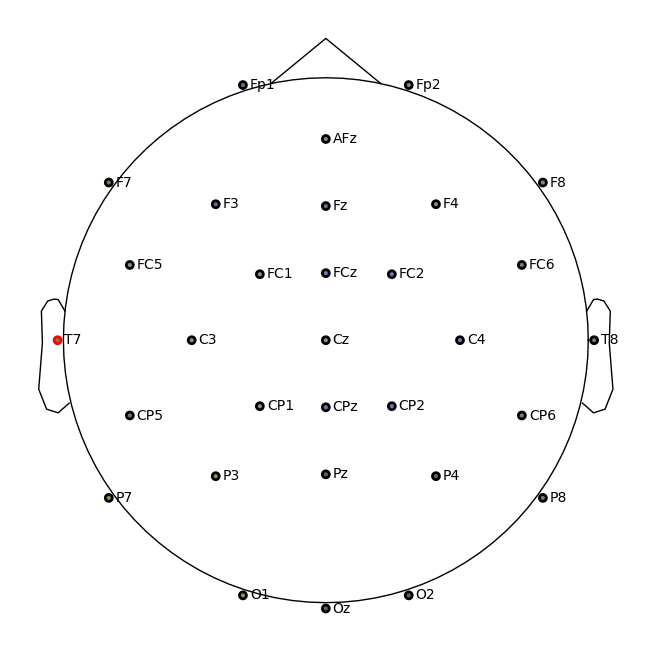

In [9]:
raw.plot_sensors(
    title="Sensor plot",
    ch_groups='position',
    show_names=True,
    sphere="auto"
);

/home/nebu/miniconda3/envs/mne/lib/python3.12/site-packages/mne/time_frequency/psd.py:292: UserWarning: nperseg = 2000 is greater than input length  = 698, using nperseg = 698
  return _func(*args, **kwargs)
/home/nebu/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


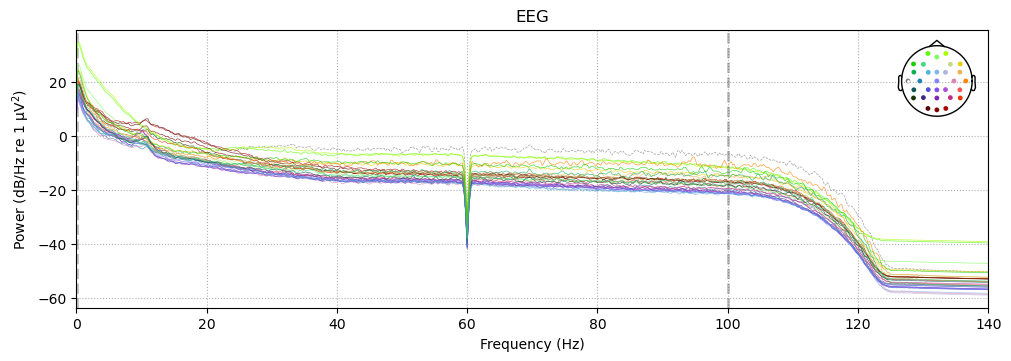

In [10]:
spectrum = raw.compute_psd(
    method="welch",
    n_fft=int(4 * raw.info["sfreq"]),
    fmin=0,
    fmax=140.0 # force Qt
)
picks_no_fz = [channel for channel in raw.ch_names if channel != "Fz"]
spectrum.plot(
    average=False,
    spatial_colors=True,
    picks=picks_no_fz
);

In [11]:
raw.info

<Info | 10 non-empty values
 bads: 1 items (T7)
 ch_names: Fp1, F3, F7, FC5, FC1, FCz, C3, T7, CP5, CP1, Pz, P3, P7, O1, ...
 chs: 31 EEG
 custom_ref_applied: True
 dig: 34 items (3 Cardinal, 31 EEG)
 highpass: 0.1 Hz
 lowpass: 100.0 Hz
 meas_date: 2025-03-31 12:01:00 UTC
 nchan: 31
 projs: []
 sfreq: 500.0 Hz
>

In [12]:
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, fir_design="firwin")

In [13]:
n_channels = len(raw.ch_names) - len(raw.info["bads"])
rank = mne.compute_rank(raw_for_ica, rank="info")
print(f"n_channels (w tym Fz): {n_channels}")
print(f"Ranga danych (auto): {rank['eeg']}")

# MNE nie loguje utraty rangi na skutek refowania (?), więc:
real_rank = rank['eeg'] - 1 # Fz reference
print(f"Prawdziwa ranga danych: {real_rank}")

n_channels (w tym Fz): 30
Ranga danych (auto): 30
Prawdziwa ranga danych: 29


In [14]:
events, event_dict = mne.events_from_annotations(raw)
epochs_for_manual_ica = mne.Epochs(
    raw_for_ica, events, event_id=event_dict,
    tmin=-0.2, tmax=0.6,
    baseline=None, preload=True,
    reject_by_annotation=True,
)

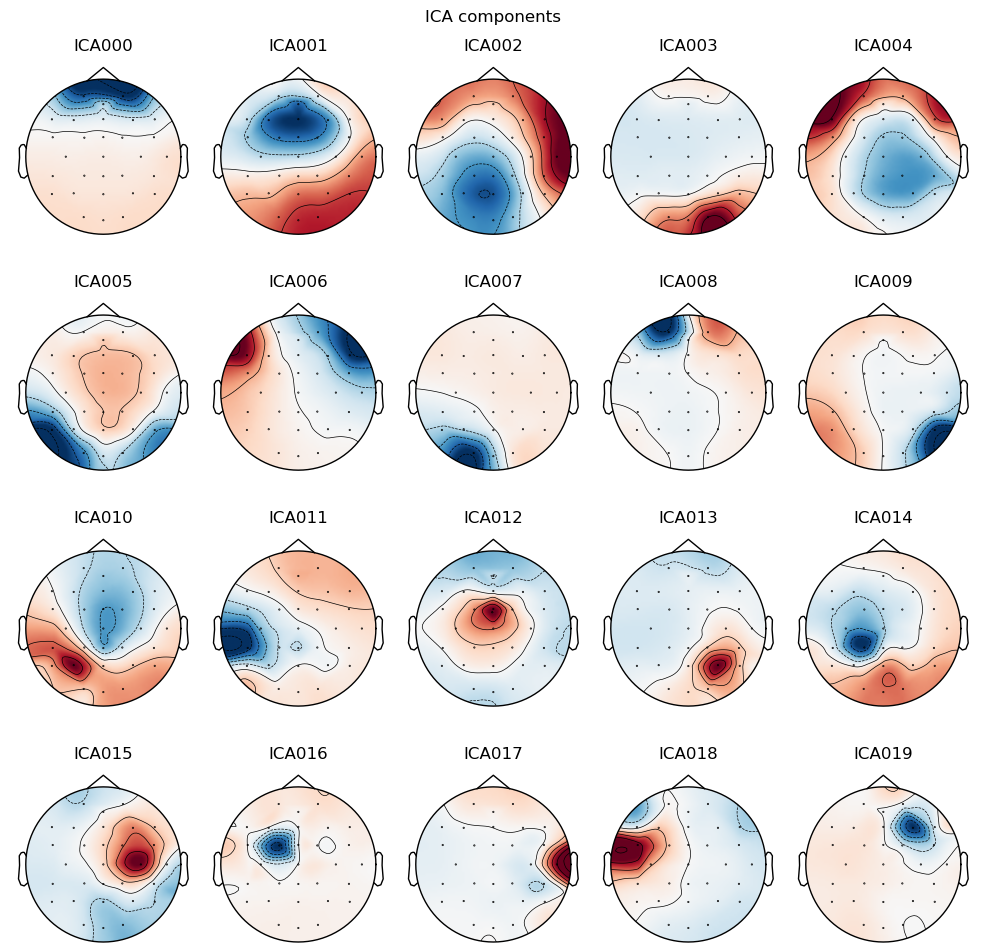

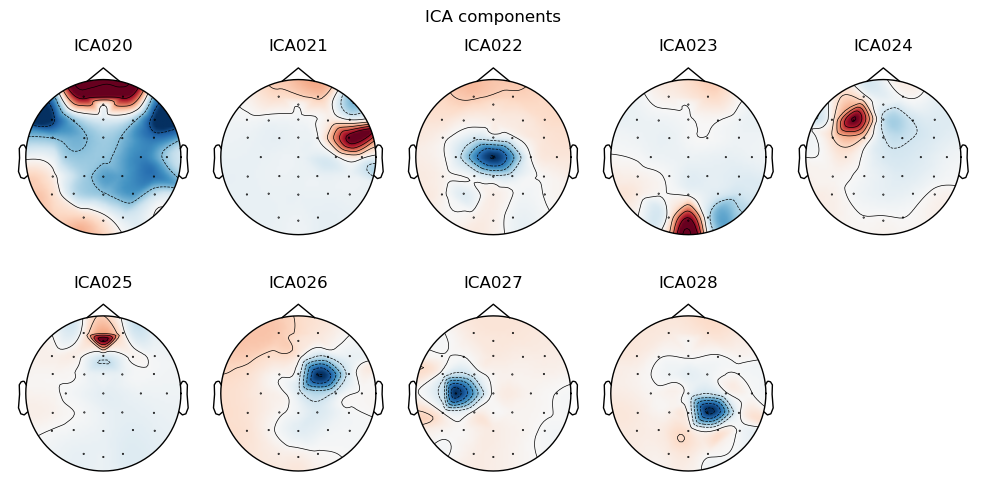

In [15]:
# uwaga: nie koniecznie deterministyczne, reprodukowalność wymaga
# conajmniej tych samych danych (raw), tego samego random_state,
# oraz tych samych parametrów (np. picard, ortho=F, extended=T)
ica = ICA(
    n_components=real_rank,
    method="picard",
    fit_params=dict(ortho=False, extended=True),
    max_iter="auto",
    random_state=97
)
ica.fit(epochs_for_manual_ica, decim=5)

# topografia
ica.plot_components();

In [17]:
ica.plot_sources(raw)

<mne_qt_browser._pg_figure.MNEQtBrowser(0x55ffa278da10) at 0x7fd569d355c0>

In [18]:
manual_excludes = sorted(list(set([0, 17, 6, 8, 12, 15, 16, 17, 18, 21, 22, 26, 28, 25, 27])))
print(f"Ręcznie wybrane komponenty ({len(manual_excludes)}/{ica.n_components_}): {manual_excludes}")

Ręcznie wybrane komponenty (14/29): [0, 6, 8, 12, 15, 16, 17, 18, 21, 22, 25, 26, 27, 28]


In [48]:
ica.exclude = manual_excludes

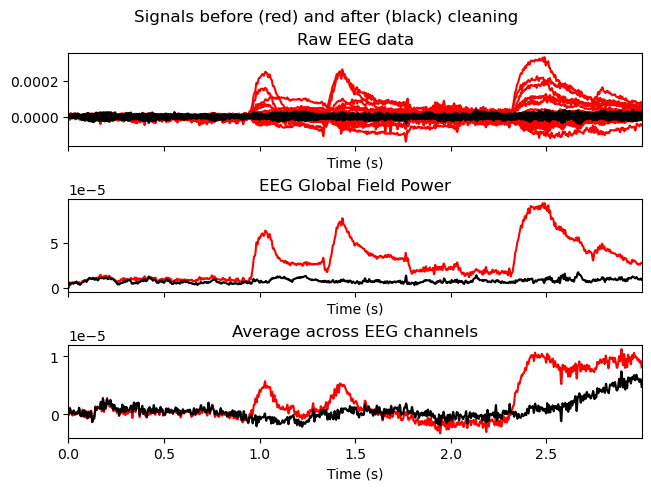

In [50]:
ica.plot_overlay(raw, exclude=ica.exclude);

In [20]:
raw_after_manual_ica = raw.copy()
ica.apply(raw_after_manual_ica)

<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 31 x 799840 (1599.7 s), ~189.2 MiB, data loaded>

In [21]:
raw_after_manual_ica.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x55ffa5dca170) at 0x7fd56898f240>